
# AI401 — Intelligent Multi-Agent and Expert Systems
## Experiment 7: Logical and Probabilistic Reasoning

**Name:** Atharv Gupta  
**Roll Number:** U23AI085  
**College:** Sardar Vallabhbhai National Institute of Technology (SVNIT), Surat

---

### Aim
To implement basic **Propositional Logic, First-Order Logic, and probability-based reasoning using Python**.

### Exercises covered
1. Propositional Logic — represent *“If it rains, then the road is wet”*, generate and verify its truth table.
2. First-Order Logic — represent *“All humans are mortal”* and *“Socrates is a human”*, then derive whether Socrates is mortal.
3. Probability of Events — calculate individual, joint, and union probabilities from a small student dataset.
4. Conditional Probability — calculate \(P(A\mid B)\) and \(P(B\mid A)\).
5. Bayes' Theorem — calculate the probability of disease after a positive test.
6. Visualization — plot the calculated probabilities and modify an input probability to observe the change.

The implementations are self-contained and executable in Python.


In [23]:

import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline



# 1. Propositional Logic

Let:

- \(P\): It rains.
- \(Q\): The road is wet.

The statement **“If it rains, then the road is wet”** is represented as:

\[
P \rightarrow Q
\]

For propositional implication:

\[
P \rightarrow Q \equiv \neg P \lor Q
\]

It is false only when \(P\) is True and \(Q\) is False.


In [24]:

def implication(p, q):
    return (not p) or q

truth_table = []

for rains, road_wet in itertools.product([False, True], repeat=2):
    truth_table.append({
        "P: Rains": rains,
        "Q: Road is Wet": road_wet,
        "P -> Q": implication(rains, road_wet)
    })

truth_table_df = pd.DataFrame(truth_table)
truth_table_df


,P: Rains,Q: Road is Wet,P -> Q
0,False,False,True
1,False,True,True
2,True,False,False
3,True,True,True


In [25]:

expected_implication = [True, True, False, True]
assert truth_table_df["P -> Q"].tolist() == expected_implication

print("Truth-table verification:")
print("1. Not raining, road not wet      -> True")
print("2. Not raining, road wet          -> True")
print("3. Raining, road not wet          -> False")
print("4. Raining, road wet              -> True")
print("\nPropositional Logic truth table verified successfully.")


Truth-table verification:
1. Not raining, road not wet      -> True
2. Not raining, road wet          -> True
3. Raining, road not wet          -> False
4. Raining, road wet              -> True

Propositional Logic truth table verified successfully.



### Observation

The only case that violates the rule is:

\[
P=True,\quad Q=False
\]

That is, **it rains but the road is not wet**. In every other combination, the implication is True.



# 2. First-Order Logic

The two statements are:

### “All humans are mortal”

\[
\forall x\;(Human(x) \rightarrow Mortal(x))
\]

### “Socrates is a human”

\[
Human(Socrates)
\]

From these, we derive:

\[
Human(Socrates) \Rightarrow Mortal(Socrates)
\]

This is a simple instance of applying a universal rule to a known individual fact.


In [26]:

# Simple representation of the FOL knowledge base
humans = {"Socrates"}

def is_mortal(person):
    # Represents the rule: if a person is human, that person is mortal.
    return person in humans

person = "Socrates"

print(f"Human({person}) = {person in humans}")
print(f"Mortal({person}) = {is_mortal(person)}")

assert is_mortal("Socrates") is True
print("\nTherefore, Socrates is mortal.")


Human(Socrates) = True
Mortal(Socrates) = True

Therefore, Socrates is mortal.



### Explanation

The set `humans` stores the known fact `Human(Socrates)`. The rule says every human is mortal. Therefore, checking whether Socrates belongs to the human set is enough to derive `Mortal(Socrates)`.

This is a small rule-based simulation of the required First-Order Logic inference rather than a full general-purpose FOL theorem prover.



# 3. Probability of Events

Let:

- \(A\): the student **attended**.
- \(B\): the student **passed**.

For an event \(E\):

\[
P(E)=\frac{\text{number of outcomes satisfying }E}{\text{total number of outcomes}}
\]

Joint probability:

\[
P(A\cap B)
\]

Union probability:

\[
P(A\cup B)=P(A)+P(B)-P(A\cap B)
\]

The same student dataset is used for the next exercise as well.


In [27]:

students = pd.DataFrame({
    "Student": [f"S{i}" for i in range(1, 21)],
    "Attended": [
        True, True, True, True, True,
        True, True, True, True, True,
        True, True, False, False, False,
        False, False, False, False, False
    ],
    "Passed": [
        True, True, True, True, True,
        True, True, False, False, False,
        False, False, True, True, False,
        False, False, True, True, False    ]
})

students


,Student,Attended,Passed
0,S1,True,True
1,S2,True,True
2,S3,True,True
3,S4,True,True
4,S5,True,True
5,S6,True,True
6,S7,True,True
7,S8,True,False
8,S9,True,False
9,S10,True,False


In [28]:

A = students["Attended"]
B = students["Passed"]
N = len(students)

p_A = A.mean()
p_B = B.mean()
p_A_and_B = (A & B).mean()
p_A_or_B = p_A + p_B - p_A_and_B

print(f"Total students N = {N}")
print(f"P(A) = P(Attended) = {p_A:.4f}")
print(f"P(B) = P(Passed) = {p_B:.4f}")
print(f"P(A ∩ B) = P(Attended and Passed) = {p_A_and_B:.4f}")
print(f"P(A ∪ B) = P(Attended or Passed) = {p_A_or_B:.4f}")

assert np.isclose(p_A, 12/20)
assert np.isclose(p_B, 11/20)
assert np.isclose(p_A_and_B, 7/20)
assert np.isclose(p_A_or_B, 16/20)

print("\nIndividual, joint, and union probabilities verified.")


Total students N = 20
P(A) = P(Attended) = 0.6000
P(B) = P(Passed) = 0.5500
P(A ∩ B) = P(Attended and Passed) = 0.3500
P(A ∪ B) = P(Attended or Passed) = 0.8000

Individual, joint, and union probabilities verified.



### Observation

For the dataset:

- 12 out of 20 students attended, so \(P(A)=0.60\).
- 11 out of 20 students passed, so \(P(B)=0.55\).
- 7 students both attended and passed, so \(P(A\cap B)=0.35\).
- 16 students either attended or passed, so \(P(A\cup B)=0.80\).

The union formula subtracts the intersection because those students belong to both events.



# 4. Conditional Probability

Conditional probability answers questions such as:

- What is the probability that a student attended **given that the student passed**?
- What is the probability that a student passed **given that the student attended**?

The formulas are:

\[
P(A\mid B)=\frac{P(A\cap B)}{P(B)}
\]

\[
P(B\mid A)=\frac{P(A\cap B)}{P(A)}
\]


In [29]:

def conditional_probability(event_a, event_b):
    p_b = event_b.mean()
    if p_b == 0:
        raise ValueError("The conditioning event must have non-zero probability.")
    return (event_a & event_b).mean() / p_b

p_A_given_B = conditional_probability(A, B)
p_B_given_A = conditional_probability(B, A)

print(f"P(A | B) = P(Attended | Passed) = {p_A_given_B:.4f}")
print(f"P(B | A) = P(Passed | Attended) = {p_B_given_A:.4f}")

assert np.isclose(p_A_given_B, 7/11)
assert np.isclose(p_B_given_A, 7/12)

print("\nConditional probabilities verified.")


P(A | B) = P(Attended | Passed) = 0.6364
P(B | A) = P(Passed | Attended) = 0.5833

Conditional probabilities verified.



### Observation

\[
P(A\mid B)=\frac{7}{11}\approx0.6364
\]

and

\[
P(B\mid A)=\frac{7}{12}\approx0.5833
\]

The two values are different, which illustrates that conditional probability depends on which event is used as the condition.



# 5. Bayes' Theorem

Consider a disease-diagnosis example.

Let:

- \(D\): the person has the disease.
- \(+\): the medical test is positive.

Use:

\[
P(D)=0.01
\]

\[
P(+\mid D)=0.95
\]

\[
P(+\mid\neg D)=0.05
\]

Bayes' theorem:

\[
P(D\mid +)=
\frac{P(+\mid D)P(D)}
{P(+\mid D)P(D)+P(+\mid\neg D)P(\neg D)}
\]

The result is the probability of disease after observing a positive test.


In [30]:

def bayes_posterior(prior_disease, sensitivity, false_positive_rate):
    if not (0 <= prior_disease <= 1):
        raise ValueError("Prior probability must be between 0 and 1.")
    if not (0 <= sensitivity <= 1):
        raise ValueError("Sensitivity must be between 0 and 1.")
    if not (0 <= false_positive_rate <= 1):
        raise ValueError("False-positive rate must be between 0 and 1.")

    numerator = sensitivity * prior_disease
    denominator = numerator + false_positive_rate * (1 - prior_disease)

    if denominator == 0:
        raise ValueError("Bayes denominator cannot be zero.")

    return numerator / denominator

prior_disease = 0.01
sensitivity = 0.95
false_positive_rate = 0.05

posterior = bayes_posterior(
    prior_disease,
    sensitivity,
    false_positive_rate
)

p_positive = (
    sensitivity * prior_disease
    + false_positive_rate * (1 - prior_disease)
)

print(f"P(D) = {prior_disease:.2%}")
print(f"P(+ | D) = {sensitivity:.2%}")
print(f"P(+ | not D) = {false_positive_rate:.2%}")
print(f"P(+) = {p_positive:.4f} ({p_positive:.2%})")
print(f"P(D | +) = {posterior:.4f} ({posterior:.2%})")

assert np.isclose(posterior, 0.16101694915254236)

print("\nBayes' theorem calculation verified.")


P(D) = 1.00%
P(+ | D) = 95.00%
P(+ | not D) = 5.00%
P(+) = 0.0590 (5.90%)
P(D | +) = 0.1610 (16.10%)

Bayes' theorem calculation verified.



### Observation

With the selected values, the posterior is:

\[
P(D\mid +)\approx0.1610=16.10\%
\]

The posterior depends on the prior disease probability and on how often the test is positive for diseased and non-diseased people.



# 6. Visualization

Matplotlib is used to create graphs for the calculated probabilities.

The first graph shows the main probabilities obtained in Exercises 3–5.

For the required modification experiment, one input probability is changed:

\[
P(+\mid D): 0.95 \rightarrow 0.80
\]

The prior and false-positive rate are kept fixed. The resulting Bayes posterior is plotted against the prior disease probability so that the effect of this change can be observed visually.


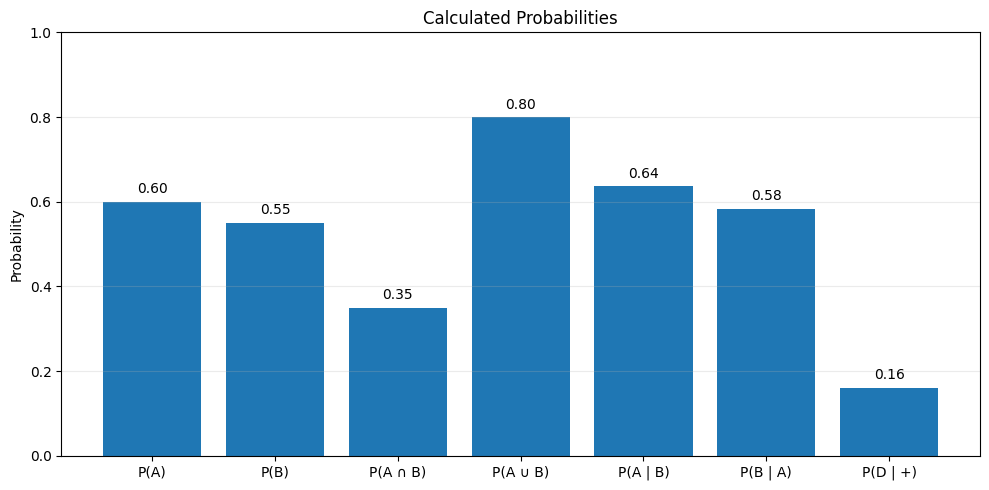

In [31]:

probability_names = [
    "P(A)", "P(B)", "P(A ∩ B)",
    "P(A ∪ B)", "P(A | B)", "P(B | A)", "P(D | +)"
]

probability_values = [
    p_A, p_B, p_A_and_B,
    p_A_or_B, p_A_given_B, p_B_given_A, posterior
]

plt.figure(figsize=(10, 5))
bars = plt.bar(probability_names, probability_values)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Calculated Probabilities")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, probability_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


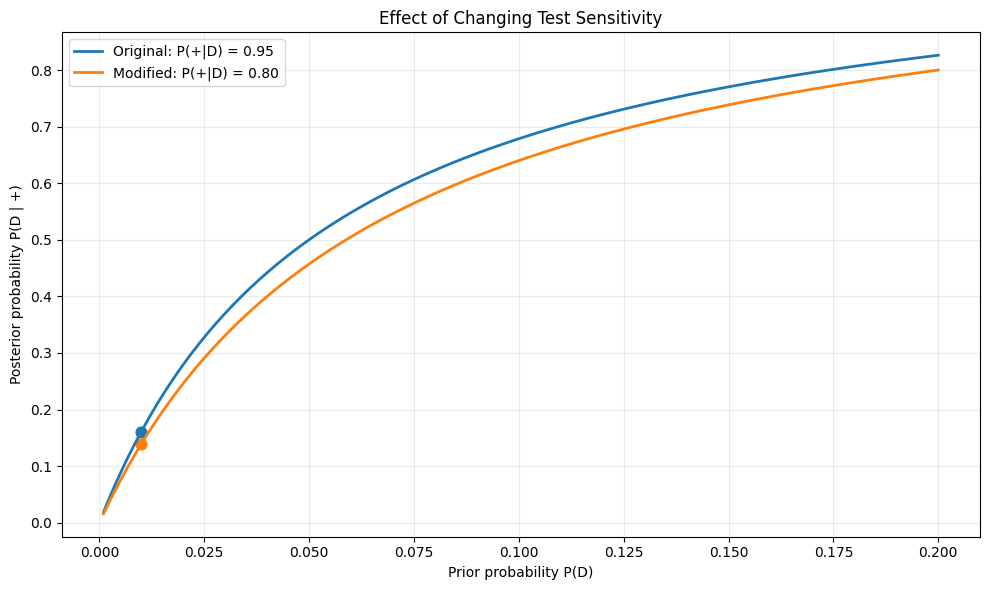

At P(D) = 1.00%:
Original P(D | +), with P(+ | D) = 0.95: 0.1610
Modified P(D | +), with P(+ | D) = 0.80: 0.1391

The graph changes as expected after modifying the input probability.


In [32]:

prior_range = np.linspace(0.001, 0.20, 200)

original_sensitivity = 0.95
modified_sensitivity = 0.80

original_curve = [
    bayes_posterior(p, original_sensitivity, false_positive_rate)
    for p in prior_range
]

modified_curve = [
    bayes_posterior(p, modified_sensitivity, false_positive_rate)
    for p in prior_range
]

plt.figure(figsize=(10, 6))
plt.plot(
    prior_range,
    original_curve,
    label="Original: P(+|D) = 0.95",
    linewidth=2
)
plt.plot(
    prior_range,
    modified_curve,
    label="Modified: P(+|D) = 0.80",
    linewidth=2
)

plt.scatter(
    [prior_disease],
    [bayes_posterior(
        prior_disease,
        original_sensitivity,
        false_positive_rate
    )],
    s=60
)

plt.scatter(
    [prior_disease],
    [bayes_posterior(
        prior_disease,
        modified_sensitivity,
        false_positive_rate
    )],
    s=60
)

plt.xlabel("Prior probability P(D)")
plt.ylabel("Posterior probability P(D | +)")
plt.title("Effect of Changing Test Sensitivity")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

original_at_selected_prior = bayes_posterior(
    prior_disease,
    original_sensitivity,
    false_positive_rate
)

modified_at_selected_prior = bayes_posterior(
    prior_disease,
    modified_sensitivity,
    false_positive_rate
)

print(f"At P(D) = {prior_disease:.2%}:")
print(
    f"Original P(D | +), with P(+ | D) = 0.95: "
    f"{original_at_selected_prior:.4f}"
)
print(
    f"Modified P(D | +), with P(+ | D) = 0.80: "
    f"{modified_at_selected_prior:.4f}"
)

assert modified_at_selected_prior < original_at_selected_prior

print("\nThe graph changes as expected after modifying the input probability.")



### Observation after modification

The test sensitivity was reduced from **0.95 to 0.80**.

For the same disease prevalence and false-positive rate, the posterior probability \(P(D\mid +)\) becomes smaller. The two curves therefore show the effect of modifying one of the input probabilities, satisfying the final observation requirement.


In [33]:

# Final automated checks
assert implication(False, False) is True
assert implication(False, True) is True
assert implication(True, False) is False
assert implication(True, True) is True

assert is_mortal("Socrates") is True

assert np.isclose(p_A, 0.60)
assert np.isclose(p_B, 0.55)
assert np.isclose(p_A_and_B, 0.35)
assert np.isclose(p_A_or_B, 0.80)

assert np.isclose(p_A_given_B, 7/11)
assert np.isclose(p_B_given_A, 7/12)

assert np.isclose(posterior, 0.16101694915254236)
assert modified_at_selected_prior < original_at_selected_prior

print("✓ Propositional Logic verified")
print("✓ First-Order Logic inference verified")
print("✓ Event probabilities verified")
print("✓ Conditional probabilities verified")
print("✓ Bayes' theorem verified")
print("✓ Visualization and modified-input comparison verified")
print("\nALL EXPERIMENT 7 TASKS PASSED.")


✓ Propositional Logic verified
✓ First-Order Logic inference verified
✓ Event probabilities verified
✓ Conditional probabilities verified
✓ Bayes' theorem verified
✓ Visualization and modified-input comparison verified

ALL EXPERIMENT 7 TASKS PASSED.
